/home/sualikhan
Using device: cuda
[Dataset] Found 22600 RGB files
[Dataset] Using max_samples=22600
[Dataset] Target image size: 256
[Loader] Train batches: 4900
[Loader] Val batches:   750
[Loader] Batch size:    4
Train samples: 19600
Val samples:   3000
/home/sualikhan/DepthModelWithCues.pth
Parameters: 4.47M
Loaded pre-trained weights.

[Epoch 116] Starting...
[Train] Starting epoch loop...
[Train] Batch 0/4900
[Model] Input shape: torch.Size([4, 3, 256, 256])
[Train] Batch 50/4900
[Train] Batch 100/4900
[Train] Batch 150/4900
[Train] Batch 200/4900
[Train] Batch 250/4900
[Train] Batch 300/4900
[Train] Batch 350/4900
[Train] Batch 400/4900
[Train] Batch 450/4900
[Train] Batch 500/4900
[Train] Batch 550/4900
[Train] Batch 600/4900
[Train] Batch 650/4900
[Train] Batch 700/4900
[Train] Batch 750/4900
[Train] Batch 800/4900
[Train] Batch 850/4900
[Dataset] Loading sample 0: train_000000_rgb.png
[Train] Batch 900/4900
[Train] Batch 950/4900
[Train] Batch 1000/4900
[Train] Batch 1050/49

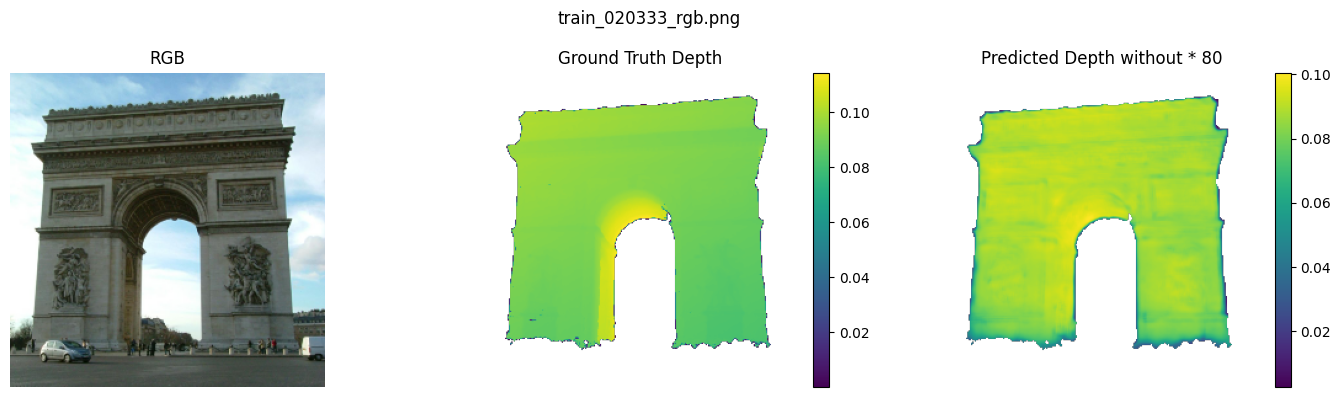

NVIDIA GeForce RTX 5060 Ti
GPU cap:  (12, 0)
Val batches: 750
Val samples: 3000
Found 591 test images
Saved 591 predictions to predictions
Saved 591 predictions → submission.csv


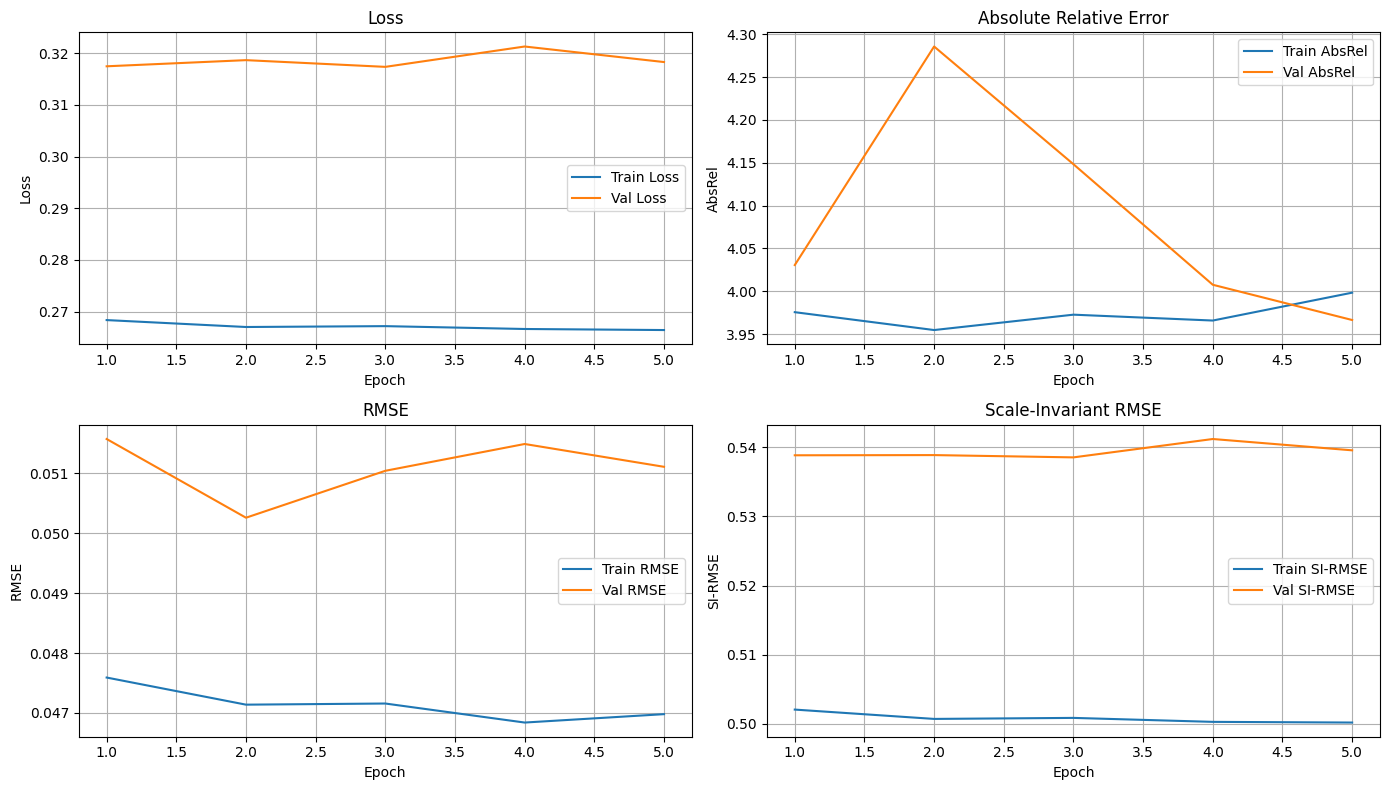

In [1]:
"""
Monocular Depth Estimation - Final Model
MonoDepth Final Training and Evaluation Script
"""

# ============================================================================
# IMPORTS AND DATA IMPORTS
# ============================================================================

import os
import csv
from pathlib import Path
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

# ---- paths ----
DATA_ROOT = Path("/cluster/courses/cil/monocular-depth-estimation/train")

# ---- training config ----
IMG_SIZE = 256   
BATCH_SIZE  = 4
NUM_EPOCHS = 5      
LR = 1e-3
MAX_TRAIN_SAMPLES = 19600
MAX_VAL_SAMPLES   = 3000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH = os.getcwd()
start_epoch = 0
LOG_FILE = "training_log.csv"
print(SAVE_PATH)

print("Using device:", DEVICE)


# ============================================================================
# DATASET
# ============================================================================

class SimpleDepthDataset(Dataset):
    def __init__(self, root: Path, img_size=128, max_samples=None):
        self.root = Path(root)
        self.img_size = img_size
        
        self.rgb_files = sorted(self.root.glob("*_rgb.png"))
        if max_samples is not None:
            self.rgb_files = self.rgb_files[:max_samples]

        print(f"[Dataset] Found {len(self.rgb_files)} RGB files")
        if max_samples:
            print(f"[Dataset] Using max_samples={max_samples}")
        print(f"[Dataset] Target image size: {self.img_size}")
        
        assert len(self.rgb_files) > 0, f"No *_rgb.png files found in {self.root}"

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
            
        rgb_path = self.rgb_files[idx]
        depth_path = Path(str(rgb_path).replace("_rgb.png", "_depth.npy"))
        
        if idx % 5000 == 0:
            print(f"[Dataset] Loading sample {idx}: {rgb_path.name}")
        # load rgb
        rgb = np.array(Image.open(rgb_path).convert("RGB"), dtype=np.float32) / 255.0
        
        # load depth
        depth = np.load(depth_path).astype(np.float32)
        
        # resize rgb
        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)   # [1,3,H,W]
        rgb_t = F.interpolate(rgb_t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        rgb_t = rgb_t.squeeze(0)  # [3,H,W]
        
        # resize depth
        depth_t = torch.from_numpy(depth).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
        depth_t = F.interpolate(depth_t, size=(self.img_size, self.img_size), mode="nearest")
        depth_t = depth_t.squeeze(0)  # [1,H,W]
        
        # valid mask: depth > 0
        valid_mask = (depth_t > 0).float()
        
        # optional normalization of valid depth values
        # keeps the target range smaller and easier for the toy model
        depth_t = torch.clamp(depth_t, min=0.0, max=80.0)
        depth_t = depth_t / 80.0
        
        return {
            "image": rgb_t,
            "depth": depth_t,
            "mask": valid_mask,
            "name": rgb_path.name
        }


# Initialize datasets
full_dataset = SimpleDepthDataset(DATA_ROOT, img_size=IMG_SIZE, max_samples=MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES)

n_total = len(full_dataset)
n_val = min(MAX_VAL_SAMPLES, max(1, int(0.15 * n_total)))
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=2, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=2, persistent_workers=True)

print(f"[Loader] Train batches: {len(train_loader)}")
print(f"[Loader] Val batches:   {len(val_loader)}")
print(f"[Loader] Batch size:    {BATCH_SIZE}")

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

# ============================================================================
# NEURAL NETWORK ARCHITECTURES
# ============================================================================

class DepthCueExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32)

        laplacian = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32)

        self.register_buffer("sobel_x", sobel_x.view(1,1,3,3))
        self.register_buffer("sobel_y", sobel_y.view(1,1,3,3))
        self.register_buffer("laplacian", laplacian.view(1,1,3,3))

    def forward(self, x):
        if not hasattr(self, "_debug_printed"):
            print("[Model] Input shape:", x.shape)
            # print("[Model] Augmented input shape:", x_aug.shape)
            self._debug_printed = True
        # x: [B,3,H,W]

        # grayscale
        gray = 0.299*x[:,0:1] + 0.587*x[:,1:2] + 0.114*x[:,2:3]

        # gradients
        gx = F.conv2d(gray, self.sobel_x, padding=1)
        gy = F.conv2d(gray, self.sobel_y, padding=1)
        grad_mag = torch.sqrt(gx**2 + gy**2)

        # laplacian (texture)
        lap = F.conv2d(gray, self.laplacian, padding=1).abs()

        # position encoding
        B, _, H, W = x.shape
        yy, xx = torch.meshgrid(
            torch.linspace(0,1,H,device=x.device),
            torch.linspace(0,1,W,device=x.device),
            indexing='ij'
        )
        xx = xx.expand(B,1,H,W)
        yy = yy.expand(B,1,H,W)

        # shading (approx shadow cue)
        blur = F.avg_pool2d(gray, kernel_size=15, stride=1, padding=7)
        shading = gray / (blur + 1e-3)

        return torch.cat([gray, grad_mag, lap, xx, yy, shading], dim=1)

class DepthModelWithCues(nn.Module):
    def __init__(self, features=(32,64,128,256)):
        super().__init__()
        self.features = features
        self.cue_extractor = DepthCueExtractor()
        self.unet = BetterUNet(in_channels=9, features=features)

    def forward(self, x):
        cues = self.cue_extractor(x)

        # normalize cues
        cues = (cues - cues.mean(dim=(2,3), keepdim=True)) / (cues.std(dim=(2,3), keepdim=True) + 1e-6)

        cues = torch.clamp(cues, -5.0, 5.0)

        x_aug = torch.cat([x, cues], dim=1)
        return self.unet(x_aug)

class CovarianceFeatures(nn.Module):
    def __init__(self, patch_size=3):
        super().__init__()
        self.patch_size = patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, padding=patch_size//2, stride=1)
    
    def forward(self, x):
        # x: [B,3,H,W]
        B, C, H, W = x.shape
        patches = self.unfold(x)  
        patches = patches.view(B, C, self.patch_size*self.patch_size, H, W)
        mean = patches.mean(dim=2, keepdim=True)  
        centered = patches - mean     
        cov_rg = (centered[:,0] * centered[:,1]).mean(dim=2, keepdim=True)  # [B,1,H,W]
        cov_rb = (centered[:,0] * centered[:,2]).mean(dim=2, keepdim=True)
        cov_gb = (centered[:,1] * centered[:,2]).mean(dim=2, keepdim=True)
        var_r = (centered[:,0]**2).mean(dim=2, keepdim=True)
        var_g = (centered[:,1]**2).mean(dim=2, keepdim=True)
        var_b = (centered[:,2]**2).mean(dim=2, keepdim=True)    
        cov_features = torch.cat([var_r, var_g, var_b, cov_rg, cov_rb, cov_gb], dim=1)  
        return cov_features


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        groups = max(1, min(8, out_ch // 4))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class DoubleConv(nn.Module):
    """BN → GN swap: GroupNorm is stable across batch sizes and in eval mode."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        groups = max(1, min(16, out_ch // 4))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class ASPPBottleneck(nn.Module):
    """Atrous Spatial Pyramid Pooling — captures multi-scale context cheaply."""
    def __init__(self, in_ch, out_ch, rates=(1, 6, 12, 18)):
        super().__init__()
        mid = in_ch // len(rates)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, mid, 3, padding=r, dilation=r, bias=False),
                nn.GroupNorm(max(1, mid // 4), mid),
                nn.SiLU(inplace=True),
            ) for r in rates
        ])
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.SiLU(inplace=True),
        )
        fused = mid * (len(rates) + 1)
        self.project = nn.Sequential(
            nn.Conv2d(fused, out_ch, 1, bias=False),
            nn.GroupNorm(max(1, out_ch // 4), out_ch),
            nn.SiLU(inplace=True),
            nn.Dropout2d(0.1),
        )
    def forward(self, x):
        h, w = x.shape[2:]
        parts = [b(x) for b in self.branches]
        pooled = F.interpolate(self.pool(x), size=(h, w), mode='bilinear', align_corners=False)
        return self.project(torch.cat(parts + [pooled], dim=1))


class BetterUNet(nn.Module):
    """
    4-level UNet with GroupNorm + SiLU throughout and an ASPP bottleneck.
    Stable across batch sizes, works correctly in eval() mode.
    ~4M params at features=[32,64,128,256].
    """
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.features = features
        f = features

        # Encoder
        self.enc1 = DoubleConv(in_channels, f[0])
        self.enc2 = DoubleConv(f[0], f[1])
        self.enc3 = DoubleConv(f[1], f[2])
        self.enc4 = DoubleConv(f[2], f[3])
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ASPPBottleneck(f[3], f[3] * 2)

        # Decoder (upsample → concat skip → conv)
        self.up4   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[3]*2, f[3], 1, bias=False))
        self.dec4  = DoubleConv(f[3]*2, f[3])

        self.up3   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[3], f[2], 1, bias=False))
        self.dec3  = DoubleConv(f[2]*2, f[2])

        self.up2   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[2], f[1], 1, bias=False))
        self.dec2  = DoubleConv(f[1]*2, f[1])

        self.up1   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[1], f[0], 1, bias=False))
        self.dec1  = DoubleConv(f[0]*2, f[0])

        self.out_conv = nn.Conv2d(f[0], out_channels, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        def up_cat_conv(up, dec, feat, skip):
            d = up(feat)
            if d.shape[2:] != skip.shape[2:]:
                d = F.interpolate(d, size=skip.shape[2:], mode='bilinear', align_corners=False)
            return dec(torch.cat([d, skip], dim=1))

        d4 = up_cat_conv(self.up4, self.dec4, b,  e4)
        d3 = up_cat_conv(self.up3, self.dec3, d4, e3)
        d2 = up_cat_conv(self.up2, self.dec2, d3, e2)
        d1 = up_cat_conv(self.up1, self.dec1, d2, e1)

        return torch.sigmoid(self.out_conv(d1))


class MediumUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128]):
        super().__init__()
        self.encoder1 = DoubleConv(in_channels, features[0])
        self.pool1 = nn.MaxPool2d(2)    
        self.encoder2 = DoubleConv(features[0], features[1])
        self.pool2 = nn.MaxPool2d(2)      
        self.encoder3 = DoubleConv(features[1], features[2])
        self.pool3 = nn.MaxPool2d(2)      
        self.bottleneck = DoubleConv(features[2], features[2]*2)     
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1)
        )
        self.decoder3 = DoubleConv(features[2]*2, features[2])     
        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(features[1]*2, features[1])    
        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(features[0]*2, features[0])    
        self.out_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool1(e1))
        e3 = self.encoder3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))
    
        d3 = self.up3(b)
        if d3.shape[2:] != e3.shape[2:]:
            d3 = F.interpolate(d3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.decoder3(d3)
    
        d2 = self.up2(d3)
        if d2.shape[2:] != e2.shape[2:]:
            d2 = F.interpolate(d2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.decoder2(d2)
    
        d1 = self.up1(d2)
        if d1.shape[2:] != e1.shape[2:]:
            d1 = F.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.decoder1(d1)
    
        out = self.out_conv(d1)
        return torch.sigmoid(out)


class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1)
        )
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                 # [B,32,H,W]
        e2 = self.enc2(self.pool1(e1))    # [B,64,H/2,W/2]
        e3 = self.enc3(self.pool2(e2))    # [B,128,H/4,W/4]
    
        b = self.bottleneck(self.pool3(e3))  # [B,256,H/8,W/8]
    
        d3 = self.up3(b)
        # Resize d3 to match e3's spatial size if needed
        if d3.shape[2:] != e3.shape[2:]:
            d3 = F.interpolate(d3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
    
        d2 = self.up2(d3)
        if d2.shape[2:] != e2.shape[2:]:
            d2 = F.interpolate(d2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
    
        d1 = self.up1(d2)
        if d1.shape[2:] != e1.shape[2:]:
            d1 = F.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
    
        out = self.out_conv(d1)
        return torch.sigmoid(out)


# Initialize model
model = DepthModelWithCues().to(DEVICE)
# model = SmallUNet().to(DEVICE)
SAVE_PATH += "/" + str(model.__class__.__name__) + ".pth"
print(SAVE_PATH)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def silog_loss(pred, target, mask, lambda_=0.85, eps=1e-6):
    """Scale-Invariant Log RMSE (SILog)."""
    valid = mask > 0
    if valid.sum() == 0:
        return pred.new_tensor(0.0)

    pred = torch.clamp(pred[valid], min=eps)
    target = torch.clamp(target[valid], min=eps)

    log_diff = torch.log(pred) - torch.log(target)
    mse = torch.mean(log_diff ** 2)
    mean = torch.mean(log_diff)
    return mse - lambda_ * (mean ** 2)


def gradient_loss(pred, target, mask, rgb=None, edge_weight=1.0):
    """
    pred, target: [B,1,H,W] depth
    mask: [B,1,H,W] valid pixels
    rgb: [B,3,H,W] – if provided, weight loss by RGB gradient magnitude
    """
    # Sobel filters for gradients
    sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=pred.dtype, device=pred.device).view(1,1,3,3)
    sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=pred.dtype, device=pred.device).view(1,1,3,3)
    
    grad_x_pred = F.conv2d(pred, sobel_x, padding=1)
    grad_y_pred = F.conv2d(pred, sobel_y, padding=1)
    grad_x_target = F.conv2d(target, sobel_x, padding=1)
    grad_y_target = F.conv2d(target, sobel_y, padding=1)
    
    # Apply mask
    mask_float = mask.float()
    grad_x_pred = grad_x_pred * mask_float
    grad_y_pred = grad_y_pred * mask_float
    grad_x_target = grad_x_target * mask_float
    grad_y_target = grad_y_target * mask_float
    
    # L1 loss on gradients
    loss_grad = F.l1_loss(grad_x_pred, grad_x_target) + F.l1_loss(grad_y_pred, grad_y_target)
    
    if rgb is not None and edge_weight > 0:
        # Weight by RGB gradient (edges get higher weight)
        rgb_gray = 0.299 * rgb[:,0:1] + 0.587 * rgb[:,1:2] + 0.114 * rgb[:,2:3]
        grad_x_rgb = F.conv2d(rgb_gray, sobel_x, padding=1).abs()
        grad_y_rgb = F.conv2d(rgb_gray, sobel_y, padding=1).abs()
        rgb_edge_weight = (grad_x_rgb + grad_y_rgb).detach()  # [B,1,H,W]
        rgb_edge_weight = rgb_edge_weight / (rgb_edge_weight.mean() + 1e-6)
        # Apply weight to gradient loss
        loss_grad = (loss_grad * rgb_edge_weight).mean()
    
    return loss_grad

# ============================================================================
# METRICS
# ============================================================================

def compute_depth_metrics(pred, target, mask, eps=1e-6):
    valid = mask > 0
    if valid.sum() == 0:
        return {"abs_rel": float("nan"), "rmse": float("nan")}

    p = pred[valid]
    t = target[valid]

    abs_rel = torch.mean(torch.abs(p - t) / torch.clamp(t, min=eps))
    rmse = torch.sqrt(torch.mean((p - t) ** 2))
    return {"abs_rel": abs_rel.item(), "rmse": rmse.item()}


def compute_scale_invariant_rmse(pred, target, mask, lambda_=1.0, eps=1e-6):
    valid = mask > 0
    if valid.sum() == 0:
        return float('nan')
    p = pred[valid]
    t = target[valid]
    log_diff = torch.log(p + eps) - torch.log(t + eps)
    mse = torch.mean(log_diff ** 2)
    mean_err = torch.mean(log_diff)
    return torch.sqrt(mse - lambda_ * (mean_err ** 2)).item()

# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)


def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    phase = "Train" if is_train else "Val"
    print(f"[{phase}] Starting epoch loop...")
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_abs_rel = 0.0
    total_rmse = 0.0
    total_si_rmse = 0.0
    n_batches = 0
    # Only use AMP scaler on CUDA; disable autocast for loss stability
    use_amp = is_train and DEVICE == "cuda"
    scaler = GradScaler('cuda') if use_amp else None

    for batch_idx, batch in enumerate(loader):
        if batch_idx % 50 == 0:
            print(f"[{phase}] Batch {batch_idx}/{len(loader)}")
        images = batch["image"].to(DEVICE)
        depths = batch["depth"].to(DEVICE)
        masks  = batch["mask"].to(DEVICE)

        #   Data augmentation (train only) 
        if is_train:
            # Random horizontal flip
            flip_mask = torch.rand(images.shape[0], device=images.device) < 0.5
            if flip_mask.any():
                images[flip_mask] = torch.flip(images[flip_mask], dims=[3])
                depths[flip_mask] = torch.flip(depths[flip_mask], dims=[3])
                masks[flip_mask]  = torch.flip(masks[flip_mask],  dims=[3])

            # Random scale + crop
            if torch.rand(1).item() < 0.5:
                scale = torch.empty(1).uniform_(0.9, 1.1).item()
                orig_h, orig_w = images.shape[2], images.shape[3]
                new_h, new_w = int(orig_h * scale), int(orig_w * scale)
                images = F.interpolate(images, size=(new_h, new_w), mode='bilinear', align_corners=False)
                depths = F.interpolate(depths, size=(new_h, new_w), mode='nearest')
                masks  = F.interpolate(masks,  size=(new_h, new_w), mode='nearest')
                top  = torch.randint(0, max(1, new_h - orig_h + 1), (1,)).item()
                left = torch.randint(0, max(1, new_w - orig_w + 1), (1,)).item()
                images = images[:, :, top:top+orig_h, left:left+orig_w]
                depths = depths[:, :, top:top+orig_h, left:left+orig_w]
                masks  = masks[:,  :, top:top+orig_h, left:left+orig_w]

            # Random brightness & contrast
            brightness = torch.empty(images.shape[0], 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
            contrast   = torch.empty(images.shape[0], 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
            image_mean = images.mean(dim=(2, 3), keepdim=True)
            images = (images - image_mean) * contrast + image_mean
            images = torch.clamp(images * brightness, 0.0, 1.0)

        #   Forward + loss (float32 — no autocast around log-based losses) 
        with torch.set_grad_enabled(is_train):
            preds = model(images)                   # always float32
            preds = torch.clamp(preds, min=1e-4, max=1.0)   # guard log domain

            valid = masks > 0
            if valid.any():
                silog = silog_loss(preds, depths, masks)
                l1    = F.l1_loss(preds[valid], depths[valid])
                grad  = gradient_loss(preds, depths, masks, rgb=images, edge_weight=0.5)

                # Guard against any stray NaN in individual terms
                silog = torch.nan_to_num(silog, nan=0.0)
                l1    = torch.nan_to_num(l1,    nan=0.0)
                grad  = torch.nan_to_num(grad,  nan=0.0)

                loss = silog + 0.15 * l1 + 0.05 * grad
            else:
                loss = preds.new_tensor(0.0)

            if torch.isnan(loss) or torch.isinf(loss):
                if is_train:
                    print(f"  Skipping batch — loss is {loss.item()}")
                    continue
                else:
                    loss = preds.new_tensor(0.0)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        #   Metrics 
        with torch.no_grad():
            metrics = compute_depth_metrics(preds.detach(), depths, masks)
            si_rmse = compute_scale_invariant_rmse(preds.detach(), depths, masks)

        total_loss    += loss.item()
        total_abs_rel += metrics["abs_rel"] if not np.isnan(metrics["abs_rel"]) else 0.0
        total_rmse    += metrics["rmse"]    if not np.isnan(metrics["rmse"])    else 0.0
        total_si_rmse += si_rmse            if not np.isnan(si_rmse)            else 0.0
        n_batches += 1

    n = max(1, n_batches)

    print(f"[{phase}] Finished. Avg Loss: {total_loss/n:.4f}, "f"AbsRel: {total_abs_rel/n:.4f}, RMSE: {total_rmse/n:.4f}")
    
    return {
        "loss":    total_loss    / n,
        "abs_rel": total_abs_rel / n,
        "rmse":    total_rmse    / n,
        "si_rmse": total_si_rmse / n,
    }

def save_validation_samples(model, val_loader, device, epoch, val_loss, num_samples=5, base_dir="validation_viz"):
    model.eval()

    save_dir = os.path.join(base_dir, f"epoch_{epoch+1}")
    os.makedirs(save_dir, exist_ok=True)

    batch = next(iter(val_loader))

    images = batch["image"].to(device)
    depths = batch["depth"].to(device)
    masks  = batch["mask"].to(device)

    with torch.no_grad():
        preds = model(images)

    # idxs = torch.randperm(images.shape[0])[:num_samples]
    idxs = torch.arange(min(num_samples, images.shape[0]))

    for i, idx in enumerate(idxs):
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        gt = depths[idx, 0].cpu().numpy()
        pred = preds[idx, 0].cpu().numpy()
        mask = masks[idx, 0].cpu().numpy()

        gt_vis = gt.copy()
        pred_vis = pred.copy()

        gt_vis[mask == 0] = np.nan
        pred_vis[mask == 0] = np.nan

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("RGB")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt_vis, cmap="viridis")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pred_vis, cmap="viridis")
        plt.title("Prediction")
        plt.axis("off")

        plt.tight_layout()

        out_path = os.path.join(
            save_dir,
            f"sample_{i}_epoch_{epoch+1}_loss_{val_loss['loss']:.3f}.png"
        )
        plt.savefig(out_path, dpi=150)
        plt.close()

    print(f"[Viz] Saved epoch {epoch+1} samples → {save_dir}")


# Load pre-trained weights if available
if Path(SAVE_PATH).exists():
    checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
    model = DepthModelWithCues().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print("Loaded pre-trained weights.")
else:
    print("No saved weights found, starting from scratch.")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_abs_rel": [],
    "val_abs_rel": [],
    "train_rmse": [],
    "val_rmse": [],
    "train_si_rmse": [],
    "val_si_rmse": []
}

if not Path(LOG_FILE).exists():
    with open(LOG_FILE, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch",
            "train_loss", "val_loss",
            "train_abs_rel", "val_abs_rel",
            "train_rmse", "val_rmse",
            "train_si_rmse", "val_si_rmse"
        ])

# Training loop
for epoch in range(start_epoch, start_epoch + NUM_EPOCHS):
    print(f"\n[Epoch {epoch+1}] Starting...")
    train_loss = run_epoch(train_loader, model, optimizer=optimizer)
    print(f"[Epoch {epoch+1}] Training done")

    val_loss = run_epoch(val_loader, model, optimizer=None)
    print(f"[Epoch {epoch+1}] Validation done")

    if (epoch+1) % 5 == 0:
    # if True:
        save_validation_samples(
            model,
            val_loader,
            DEVICE,
            epoch,
            val_loss,
            num_samples=5
        )

    scheduler.step(val_loss["loss"])
    # scheduler.step()
    
    print(
        f"Epoch {epoch+1}/{start_epoch + NUM_EPOCHS} | "
        f"train loss: {train_loss['loss']:.4f}, AbsRel: {train_loss['abs_rel']:.4f}, RMSE: {train_loss['rmse']:.4f}, si_rmse: {train_loss['si_rmse']:.4f} | "
        f"val loss: {val_loss['loss']:.4f}, AbsRel: {val_loss['abs_rel']:.4f}, RMSE: {val_loss['rmse']:.4f}, si_rmse: {val_loss['si_rmse']:.4f} "
    )

    history["train_loss"].append(train_loss["loss"])
    history["val_loss"].append(val_loss["loss"])
    
    history["train_abs_rel"].append(train_loss["abs_rel"])
    history["val_abs_rel"].append(val_loss["abs_rel"])
    
    history["train_rmse"].append(train_loss["rmse"])
    history["val_rmse"].append(val_loss["rmse"])
    
    history["train_si_rmse"].append(train_loss["si_rmse"])
    history["val_si_rmse"].append(val_loss["si_rmse"])

    with open(LOG_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch,
            train_loss["loss"], val_loss["loss"],
            train_loss["abs_rel"], val_loss["abs_rel"],
            train_loss["rmse"], val_loss["rmse"],
            train_loss["si_rmse"], val_loss["si_rmse"]
        ])
    
    if (epoch + 1) % 5 == 0 or (epoch + 1) == (start_epoch + NUM_EPOCHS):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'model_config': {'features': model.features},
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_loss['loss']
        }
        torch.save(checkpoint, SAVE_PATH)
        print(f"[Checkpoint] Saved at epoch {epoch+1}")

# ============================================================================
# EVALUATION ON VALIDATION SET
# ============================================================================

model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(DEVICE)
depths = batch["depth"].to(DEVICE)
masks = batch["mask"].to(DEVICE)
names = batch["name"]

with torch.no_grad():
    preds = model(images)

i = 0
img = images[i].cpu().permute(1, 2, 0).numpy()
gt = depths[i, 0].cpu().numpy()
pred = preds[i, 0].cpu().numpy()
mask = masks[i, 0].cpu().numpy()

# hide invalid gt pixels
gt_vis = gt.copy()
gt_vis[mask == 0] = np.nan
pred[mask == 0] = np.nan

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_vis, cmap="viridis")
plt.title("Ground Truth Depth")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="viridis")
plt.title("Predicted Depth without * 80")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.suptitle(names[i])
plt.tight_layout()
plt.show()
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(f"GPU cap:  {torch.cuda.get_device_capability(0)}")
    print("Val batches:", len(val_loader))
    print("Val samples:", len(val_dataset))

# ============================================================================
# SUBMISSION PIPELINE
# ============================================================================

TEST_ROOT  = Path("/cluster/courses/cil/monocular-depth-estimation/test")
PRED_DIR   = Path("./predictions")
PRED_DIR.mkdir(exist_ok=True)

# IMG_SIZE = 320

model.eval()

test_rgb_files = sorted(TEST_ROOT.glob("test_*_rgb.png"))  
print(f"Found {len(test_rgb_files)} test images")

with torch.no_grad():
    for img_path in test_rgb_files:
        rgb = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        
        # ✅ save original size
        orig_h, orig_w = rgb.shape[:2]

        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)
        rgb_t = F.interpolate(rgb_t, size=(IMG_SIZE, IMG_SIZE),
                              mode="bilinear", align_corners=False).to(DEVICE)

        pred = model(rgb_t)

        pred = F.interpolate(pred, size=(orig_h, orig_w),
                             mode="bicubic", align_corners=False)

        pred = torch.clamp(pred, min=0.0, max=1.0)
        
        pred = pred.squeeze().cpu().numpy()
        pred = pred * 80.0

        # optional safety check
        assert pred.shape == (orig_h, orig_w), f"Shape mismatch: {pred.shape}"

        idx = img_path.stem.split("_")[-2]   
        out_path = PRED_DIR / f"test_{idx}.npy"
        np.save(out_path, pred.astype(np.float32))

print(f"Saved {len(test_rgb_files)} predictions to {PRED_DIR}")

# Create submission CSV
import base64, zlib, pandas as pd

def encode_depth(depth: np.ndarray) -> str:
    depth = np.asarray(depth, dtype=np.float16)
    compressed = zlib.compress(depth.tobytes(), level=9)
    return base64.b64encode(compressed).decode("utf-8")

pred_dir = Path("./predictions")   # same as PRED_DIR above
out_csv  = Path("./submission.csv")

rows = []
for pred_path in sorted(pred_dir.glob("test_*.npy")):
    depth = np.load(pred_path)
    idx   = pred_path.stem.split("_")[-1]
    rows.append({"id": f"test_{idx}_depth", "Depths": encode_depth(depth)})

df = pd.DataFrame(rows, columns=["id", "Depths"])
df.to_csv(out_csv, index=False)
print(f"Saved {len(df)} predictions → {out_csv}")

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 8))

# ---- Loss ----
plt.subplot(2, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---- AbsRel ----
plt.subplot(2, 2, 2)
plt.plot(epochs, history["train_abs_rel"], label="Train AbsRel")
plt.plot(epochs, history["val_abs_rel"], label="Val AbsRel")
plt.title("Absolute Relative Error")
plt.xlabel("Epoch")
plt.ylabel("AbsRel")
plt.legend()
plt.grid(True)

# ---- RMSE ----
plt.subplot(2, 2, 3)
plt.plot(epochs, history["train_rmse"], label="Train RMSE")
plt.plot(epochs, history["val_rmse"], label="Val RMSE")
plt.title("RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)

# ---- SI-RMSE ----
plt.subplot(2, 2, 4)
plt.plot(epochs, history["train_si_rmse"], label="Train SI-RMSE")
plt.plot(epochs, history["val_si_rmse"], label="Val SI-RMSE")
plt.title("Scale-Invariant RMSE")
plt.xlabel("Epoch")
plt.ylabel("SI-RMSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
